In [ ]:
#########################################################################
# # ! Moon Topographic-Gravitational-Potential Computation: PH vs SH
#########################################################################
# %% 
# # ! Setup
import numpy as np
import pyshtools as pysh
import pygmt
import xarray as xr
import time
from datetime import datetime
from gravity_forward_numba import *

In [ ]:
# # ! Start time
print("=" * 80)
print(f"Start time: [{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}]")
print("=" * 80)

Start time: [2026-05-12 11:36:17]


In [ ]:
# # ! Constants
myG = 6.67430e-11
r_calc_km = 1748000.0 / 1.e3

In [ ]:
# # ! Shape of Moon
#### * Shape
lmax_shp = 359
clm_shp_moon = \
    pysh.SHCoeffs.from_file(f'input/Moon_shape_719.sh', 
                            lmax=lmax_shp, 
                            name='LOLA_shape (Moon)',
                            units='m', format='bshc')
r_itfc_km = clm_shp_moon.coeffs[0,0,0] / 1.e3
in_res = 6.0/60.0 # degree
lmax_grid = int(90.0/in_res - 1)
grd_shp_moon = clm_shp_moon.expand(lmax=lmax_grid, 
                                   lmax_calc=lmax_shp)
grd_topo_moon = grd_shp_moon/ 1.e3 - r_itfc_km

In [ ]:
# # ! Load TGP data: SH vs PH
#### * SH
max_nmax = 7
nc_file_SH = f'output/moon_topo_gravity_Lshp{lmax_shp}_nmax{max_nmax}.nc'
data_SH = xr.open_dataset(nc_file_SH)
gn_SH = data_SH['gx'].data[::max_nmax, ::max_nmax]
ge_SH = data_SH['gy'].data[::max_nmax, ::max_nmax]
gd_SH = data_SH['gz'].data[::max_nmax, ::max_nmax]
#### * PH
out_res = 15.0/60.0 # degree
nc_file_PH = (f"output/moon_topo_gravity_in{int(in_res*60)}arcmin"
              f"_out{int(out_res*60)}arcmin.nc")
data_PH = xr.open_dataset(nc_file_PH)
gn_PH = data_PH['gN'].data
ge_PH = data_PH['gE'].data
gd_PH = data_PH['gD'].data
#### * Diff = PH - SH
d_gn, d_ge, d_gd = gn_PH - gn_SH, ge_PH - ge_SH, gd_PH - gd_SH
d_gn[[0, -1], :] = 0.0
d_ge[[0, -1], :] = 0.0
#### * Summary statistics
g_SH = {'N': gn_SH, 'E': ge_SH, 'D': gd_SH}
g_PH = {'N': gn_PH, 'E': ge_PH, 'D': gd_PH}
d_g  = {'N': d_gn,  'E': d_ge,  'D': d_gd}
print('-' * 80)
print('Gravity Vector components in mGal')
print(f"{'Type':4s} | {'Comp':4s} | {'min':>9s} | {'max':>9s} | {'mean':>9s} | {'std':>9s}")
print('-' * 80)
datasets = {'SH': g_SH, 'PH': g_PH, 'Diff': d_g}
for typ in ['SH', 'PH', 'Diff']:
    for comp in ['N', 'E', 'D']:
        data = datasets[typ][comp]
        print(f"{typ:4s} | {f'g{comp}':4s} | {data.min():9.4f} | {data.max():9.4f} | "
              f"{data.mean():9.4f} | {data.std():9.4f}")
    print('=' * 60)

--------------------------------------------------------------------------------
Gravity Vector components in mGal
Type | Comp |       min |       max |      mean |       std
--------------------------------------------------------------------------------
SH   | gN   | -488.8082 |  933.4147 |   10.3820 |  154.3514
SH   | gE   | -551.9941 |  606.5575 |    0.0197 |  150.2317
SH   | gD   | -721.8590 | 1189.4579 |  -35.0952 |  246.4136
PH   | gN   | -488.5107 |  932.2260 |   10.3829 |  154.4438
PH   | gE   | -551.4422 |  606.3592 |    0.0197 |  150.3391
PH   | gD   | -721.8638 | 1187.8352 |  -35.2429 |  246.3798
Diff | gN   |   -1.9898 |    2.0846 |    0.0006 |    0.1456
Diff | gE   |   -2.1117 |    1.6070 |   -0.0000 |    0.1181
Diff | gD   |   -3.3589 |    2.3430 |   -0.1477 |    0.1887


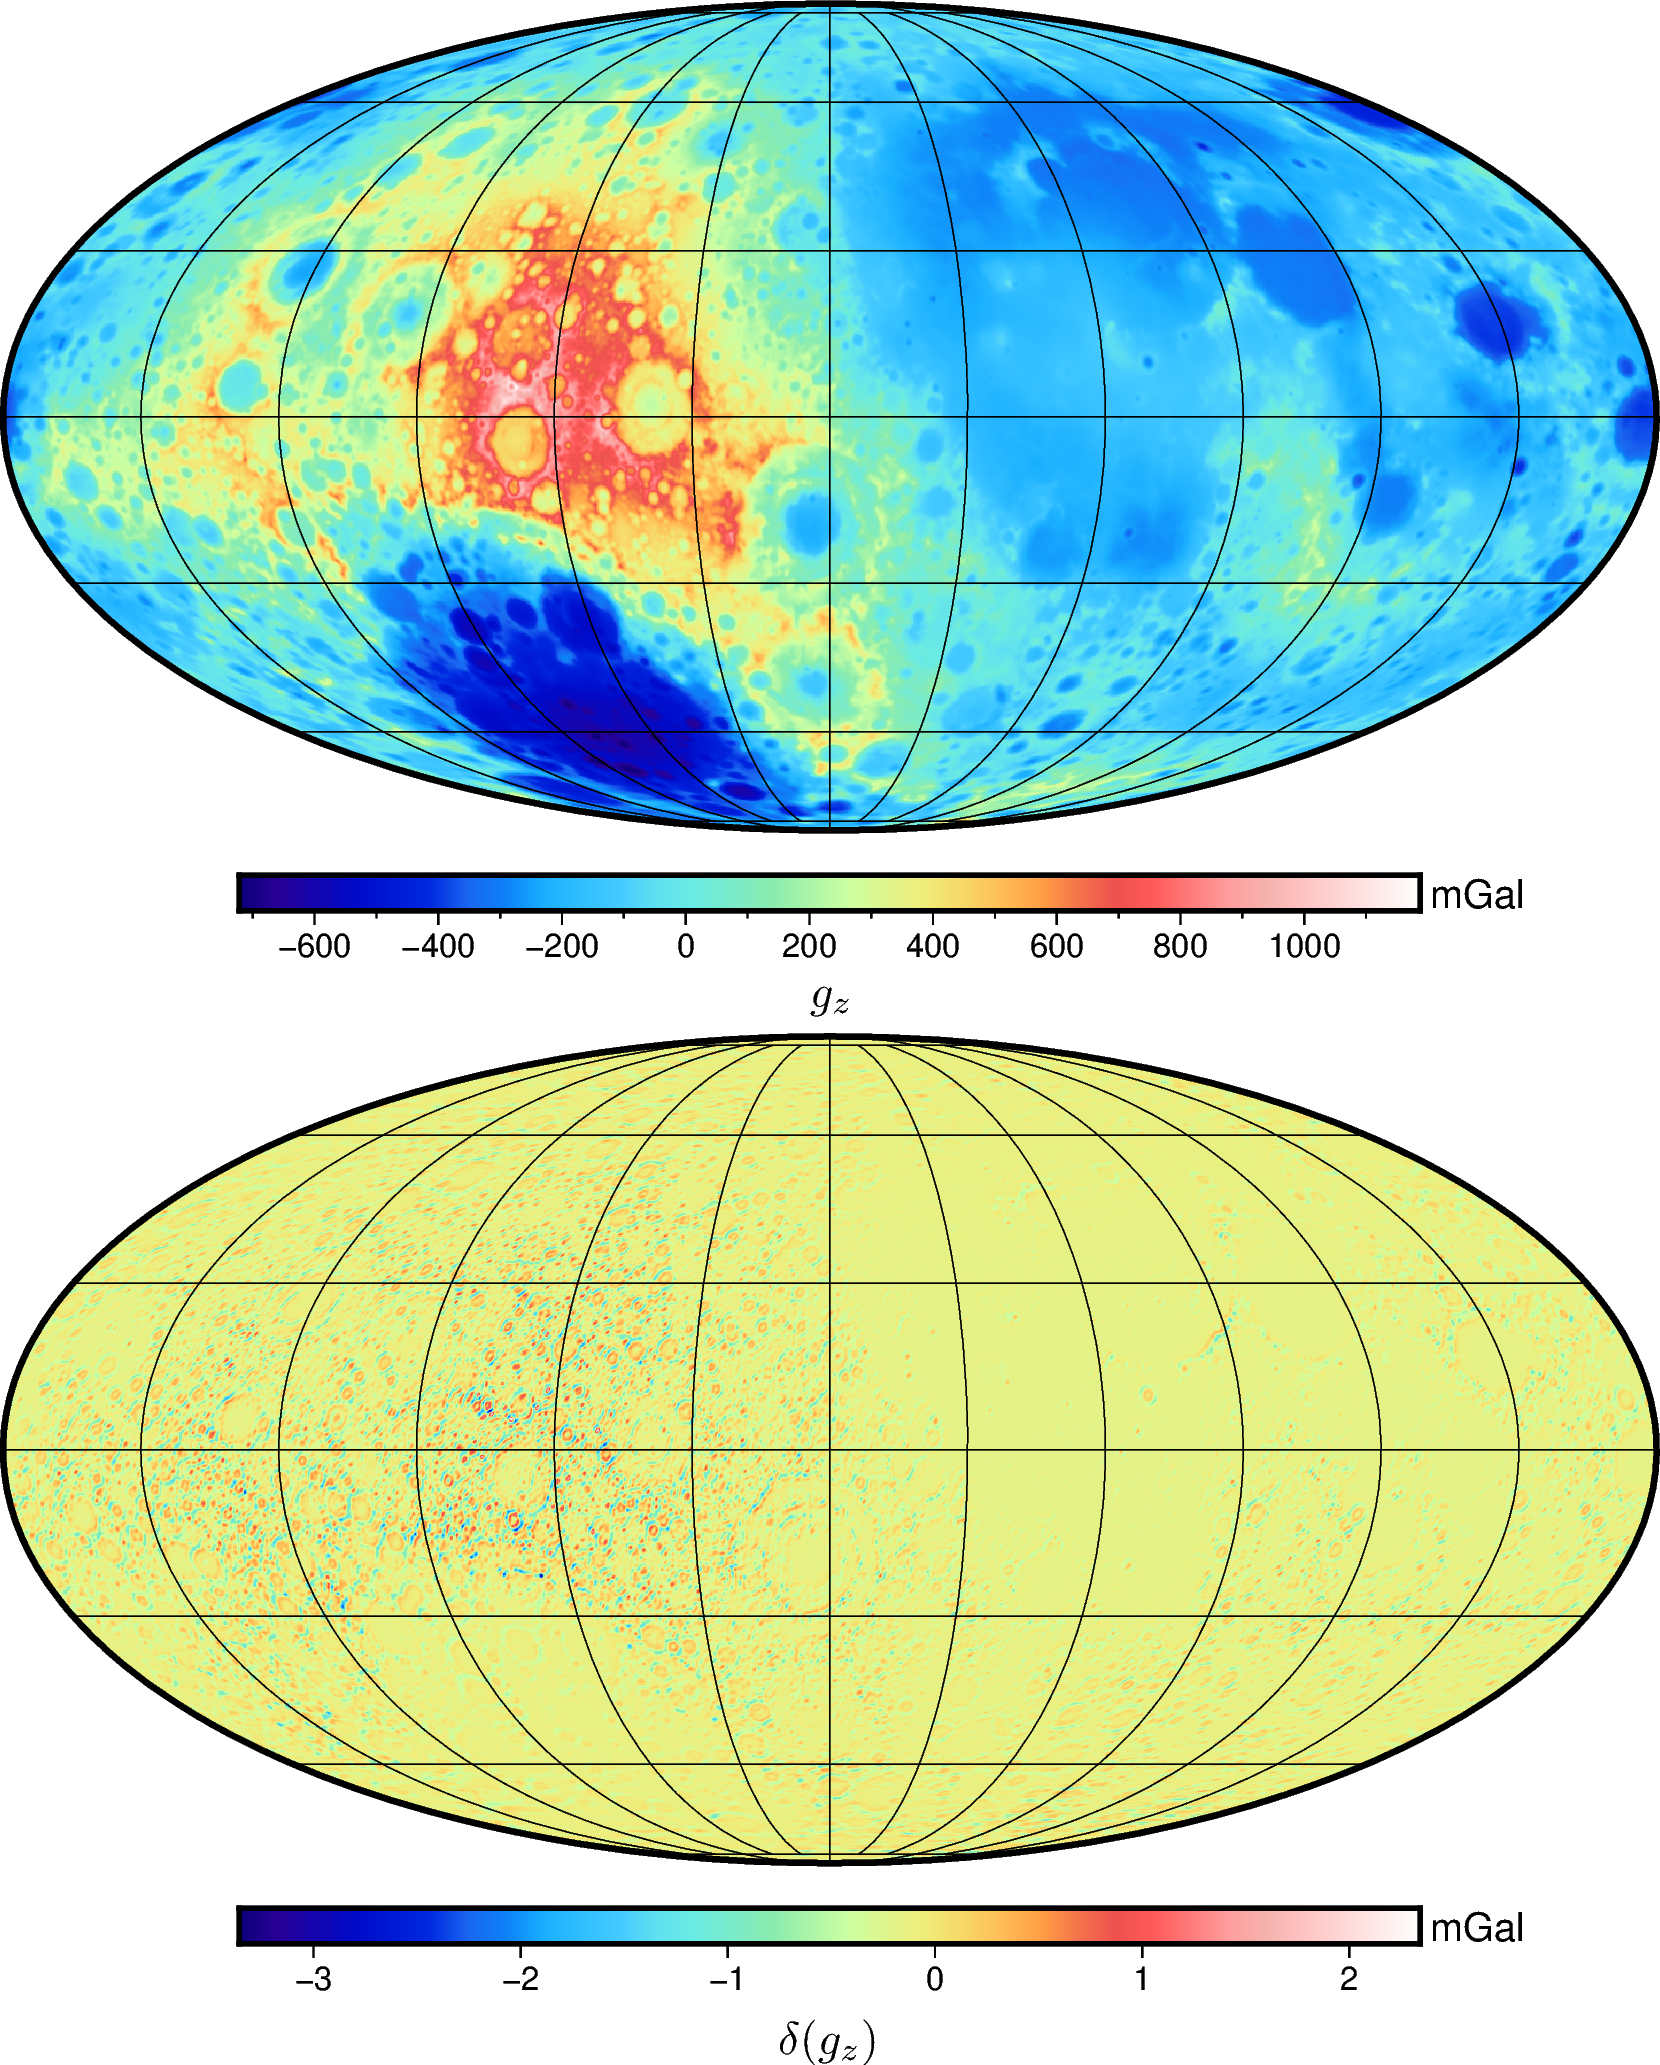

In [ ]:
# # ! Mapping: SH vs PH
err_txt = ['A','B','C','D','E','F','G','H','I','J']
xr_gd_PH = pysh.SHGrid.from_array(gd_PH).to_xarray()
xr_d_gd = pysh.SHGrid.from_array(d_gd).to_xarray()
fig = pygmt.Figure()
with fig.subplot(nrows=2, ncols=1, figsize=('14c', '16c'), margins="0.5c"):
    with fig.set_panel(panel=0): 
        fig.grdimage(grid=xr_gd_PH, projection="W-90/14c", cmap="haxby", frame="g30")
        fig.colorbar(position="JBC+o0/0.2i+w10c/0.3h", 
                     frame=["a200f100", "x+l@[ g_z @[", "y+lmGal"])    
    with fig.set_panel(panel=1): 
        fig.grdimage(grid=xr_d_gd, projection="W-90/14c", cmap="haxby", frame="g30")
        fig.colorbar(position="JBC+o0/0.2i+w10c/0.3h", 
                     frame=["a1f1", "x+l@[ \\delta(g_z) @[", "y+lmGal"])    
# fig.savefig('Moon_TopoGz_PH_vs_SH_2.png', dpi=400)
fig.show(width=800)

In [ ]:
# # ! End time
print("=" * 80)
print(f"End time: [{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}]")
print("=" * 80)

End time: [2026-05-12 11:36:20]
